# Monte Carlo Particle Detector Analysis for BL3 with Python

This project analyzes million-event Monte Carlo simulations of proton hits on a segmented silicon detector for the BL3 Neutron Lifetime Experiment. I use Python to compare several detector configurations, examine the spatial distribution of detector hits, and estimate event rates at the ring and individual-pixel level.

### What this project demonstrates

- Reading scientific ROOT files in Python with `uproot`
- Filtering and validating million-event datasets with NumPy
- Transforming Cartesian `(x, y)` coordinates into detector `(r, φ)` geometry
- Building 2D histograms with logarithmic count scaling
- Vectorized classification of events into 62 detector pixels
- Organizing scientific analysis into reusable Python functions


## 1. Background and analysis plan

I compare proton-hit distributions at the nominal detector position and at three displaced configurations labeled **3 cm**, **6 cm**, and **15 cm**.

At the nominal position, I also map simulated hits onto the detector geometry. The detector contains six concentric rings with **62 total pixels**. I use radial boundaries of **3.7, 9.1, 15, 24, 35, and 50 mm** to assign hits to detector rings and pixels.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import uproot

pd.set_option("display.precision", 4)

## 2. Configuration and detector geometry

Each simulation stores hit coordinates in the detector's global coordinate system. I use the configuration-specific detector-center values below to transform the stored `y` coordinate into a detector-centered coordinate for the spatial analysis.

The same physical ring boundaries are used for detector overlays, ring assignment, and pixel classification.


In [ ]:
# Detector-ring boundaries and number of pixels in each ring
PIXEL_RING_EDGES_MM = np.array([0.0, 3.7, 9.1, 15.0, 24.0, 35.0, 50.0])
PIXELS_PER_RING = np.array([1, 5, 10, 20, 10, 16])

PROTONS_PER_SECOND = 280.0

## 3. Load and validate the ROOT data

I keep the large ROOT files outside the GitHub repository and load them from a local `data/` directory. The helper functions below locate each file and read the branches needed for the analysis.


In [ ]:
def load_root_file(filename, y_center):
    path = Path("data") / filename
    tree = uproot.open(path)["Event;6"]

    xh = tree["xh"].array(library="np")
    yh = tree["yh"].array(library="np")
    si_edep = tree["SiEdep"].array(library="np")

    return {
        "y_center": y_center,
        "xh": xh,
        "yh": yh,
        "SiEdep": si_edep,
    }


nominal = load_root_file("nominal.root", 121.00)
detector_3cm = load_root_file("detector_3cm.root", 130.27)
detector_6cm = load_root_file("detector_6cm.root", 139.54)
detector_15cm = load_root_file("detector_15cm.root", 167.35)


# Confirm that each simulation loaded the expected number of events
load_summary = pd.DataFrame({
    "configuration": ["Nominal", "3 cm", "6 cm", "15 cm"],
    "events": [
        len(nominal["xh"]),
        len(detector_3cm["xh"]),
        len(detector_6cm["xh"]),
        len(detector_15cm["xh"]),
    ],
})

load_summary


,configuration,events
0,Nominal,1000000
1,3 cm,1000000
2,6 cm,1000000
3,15 cm,1000000


## 4. Filter detector hits and summarize each configuration

For the spatial-distribution analysis, I select events with `SiEdep > 0`, indicating a nonzero energy deposition in the silicon detector. I then calculate the mean and standard deviation of the detector-centered hit coordinates for each configuration.


In [4]:
def get_detector_hits(cfg):
    mask = cfg["SiEdep"] > 0

    x = cfg["xh"][mask]
    y = cfg["yh"][mask] - cfg["y_center"]

    return {
        "mask": mask,
        "x": x,
        "y": y,
    }


def summarize_configuration(cfg):
    hits = get_detector_hits(cfg)

    return {
        "events": len(cfg["xh"]),
        "SiEdep > 0": int(hits["mask"].sum()),
        "x mean [mm]": np.mean(hits["x"]),
        "y mean [mm]": np.mean(hits["y"]),
        "x std [mm]": np.std(hits["x"]),
        "y std [mm]": np.std(hits["y"]),
    }


nominal_summary = summarize_configuration(nominal)
summary_3cm = summarize_configuration(detector_3cm)
summary_6cm = summarize_configuration(detector_6cm)
summary_15cm = summarize_configuration(detector_15cm)

summary = pd.DataFrame(
    [nominal_summary, summary_3cm, summary_6cm, summary_15cm],
    index=["Nominal", "3 cm", "6 cm", "15 cm"]
)

summary


,events,SiEdep > 0,x mean [mm],y mean [mm],x std [mm],y std [mm]
Nominal,1000000,921380,3.0896,0.5265,13.1289,12.4572
3 cm,1000000,920867,2.9834,1.5073,13.3788,12.6537
6 cm,1000000,921476,4.0090,3.1669,13.8189,13.0452
15 cm,1000000,921449,7.0866,15.6059,17.0067,16.4103


## 5. Spatial hit distributions

To make the configurations directly comparable, I use the same histogram range, binning, logarithmic count scale, and detector-ring overlays for each dataset.

The displayed distributions are restricted to the detector's **50 mm outer radius**, so the figures focus on hits within the detector area used in the ring and pixel analysis.


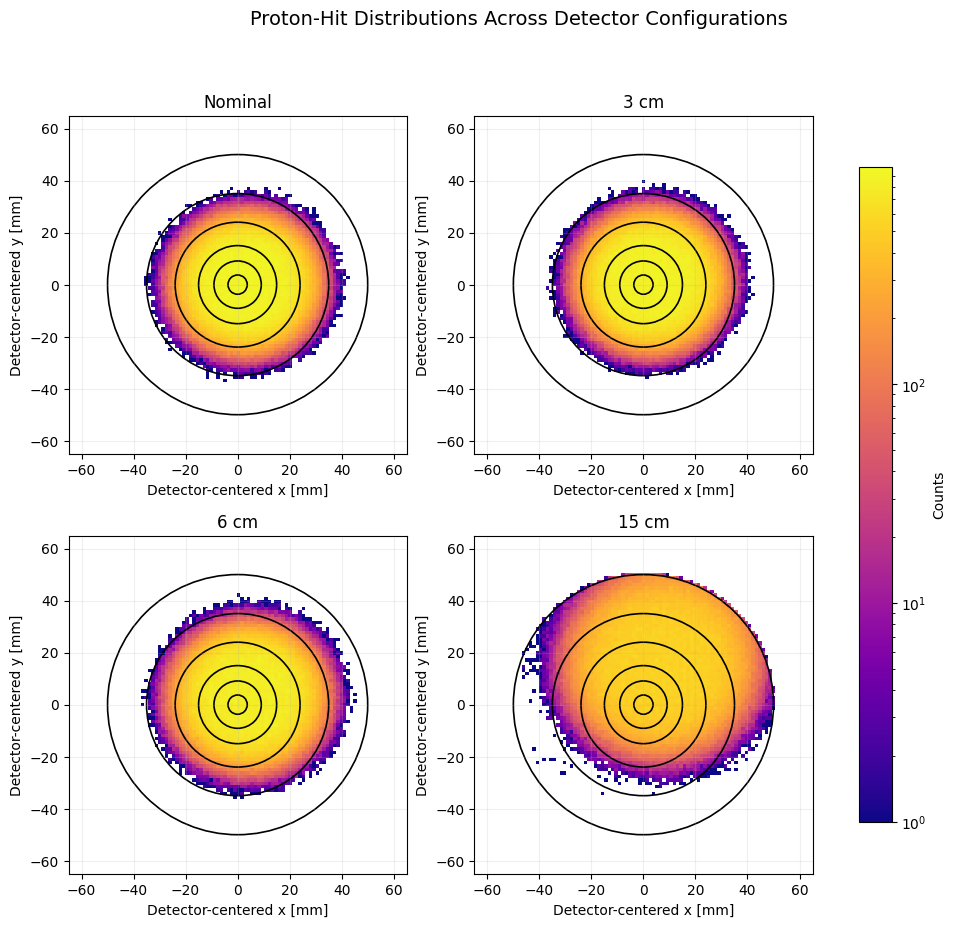

In [ ]:
edges = np.linspace(-65, 65, 100)

nominal_hits = get_detector_hits(nominal)
hits_3cm = get_detector_hits(detector_3cm)
hits_6cm = get_detector_hits(detector_6cm)
hits_15cm = get_detector_hits(detector_15cm)

nominal_r = np.sqrt(nominal_hits["x"]**2 + nominal_hits["y"]**2)
r_3cm = np.sqrt(hits_3cm["x"]**2 + hits_3cm["y"]**2)
r_6cm = np.sqrt(hits_6cm["x"]**2 + hits_6cm["y"]**2)
r_15cm = np.sqrt(hits_15cm["x"]**2 + hits_15cm["y"]**2)

nominal_on_detector = nominal_r < 50.0
on_detector_3cm = r_3cm < 50.0
on_detector_6cm = r_6cm < 50.0
on_detector_15cm = r_15cm < 50.0

# Build one 2D histogram for each configuration
nominal_hist, _, _ = np.histogram2d(
    nominal_hits["x"][nominal_on_detector],
    nominal_hits["y"][nominal_on_detector],
    bins=(edges, edges)
)

hist_3cm, _, _ = np.histogram2d(
    hits_3cm["x"][on_detector_3cm],
    hits_3cm["y"][on_detector_3cm],
    bins=(edges, edges)
)

hist_6cm, _, _ = np.histogram2d(
    hits_6cm["x"][on_detector_6cm],
    hits_6cm["y"][on_detector_6cm],
    bins=(edges, edges)
)

hist_15cm, _, _ = np.histogram2d(
    hits_15cm["x"][on_detector_15cm],
    hits_15cm["y"][on_detector_15cm],
    bins=(edges, edges)
)

# Use the largest bin count from any panel as the shared maximum
global_max = max(
    nominal_hist.max(),
    hist_3cm.max(),
    hist_6cm.max(),
    hist_15cm.max()
)

norm = LogNorm(vmin=1, vmax=global_max)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax_nominal = axes[0, 0]
ax_3cm = axes[0, 1]
ax_6cm = axes[1, 0]
ax_15cm = axes[1, 1]

extent = [edges[0], edges[-1], edges[0], edges[-1]]

image = ax_nominal.imshow(
    nominal_hist.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm
)

ax_3cm.imshow(
    hist_3cm.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm
)

ax_6cm.imshow(
    hist_6cm.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm
)

ax_15cm.imshow(
    hist_15cm.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm
)

# Draw the same detector-ring boundaries on every panel.
for ax in [ax_nominal, ax_3cm, ax_6cm, ax_15cm]:
    for radius in PIXEL_RING_EDGES_MM[1:]:
        circle = plt.Circle(
            (0, 0),
            radius,
            fill=False,
            linewidth=1.2,
            color="black"
        )
        ax.add_patch(circle)

ax_nominal.set_title("Nominal")
ax_3cm.set_title("3 cm")
ax_6cm.set_title("6 cm")
ax_15cm.set_title("15 cm")

for ax in [ax_nominal, ax_3cm, ax_6cm, ax_15cm]:
    ax.set_xlabel("Detector-centered x [mm]")
    ax.set_ylabel("Detector-centered y [mm]")
    ax.grid(alpha=0.2)

fig.colorbar(
    image,
    ax=[ax_nominal, ax_3cm, ax_6cm, ax_15cm],
    label="Counts",
    shrink=0.85
)

fig.suptitle(
    "Proton-Hit Distributions Across Detector Configurations",
    fontsize=14
)

Path("figures").mkdir(exist_ok=True)
fig.savefig(
    "figures/detector_configuration_comparison.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


## 6. Ring-level rates at the nominal position

I next examine how the nominal-position hits are distributed across the detector's six rings. For each ring, I count the assigned hits, divide by the number of pixels in that ring, and normalize the result to a nominal incident rate of **280 protons/s**.

For consistency with the normalization used in my research analysis, I calculate the nominal normalization count from a 2D histogram spanning `[-65, 65] mm`.


In [ ]:
nominal_hits = get_detector_hits(nominal)
x_nominal = nominal_hits["x"]
y_nominal = nominal_hits["y"]

# Convert detector-centered x and y coordinates to radius and angle
r_nominal = np.sqrt(x_nominal**2 + y_nominal**2)
phi_nominal = np.degrees(np.arctan2(y_nominal, x_nominal))
phi_nominal = (phi_nominal + 360.0) % 360.0

# Each Boolean mask represents one physical detector ring
ring_1 = (r_nominal >= 0.0) & (r_nominal < 3.7)
ring_2 = (r_nominal >= 3.7) & (r_nominal < 9.1)
ring_3 = (r_nominal >= 9.1) & (r_nominal < 15.0)
ring_4 = (r_nominal >= 15.0) & (r_nominal < 24.0)
ring_5 = (r_nominal >= 24.0) & (r_nominal < 35.0)
ring_6 = (r_nominal >= 35.0) & (r_nominal < 50.0)

# Count how many hits fall in each ring.
ring_counts = np.array([
    ring_1.sum(),
    ring_2.sum(),
    ring_3.sum(),
    ring_4.sum(),
    ring_5.sum(),
    ring_6.sum(),
])

avg_hits_per_pixel = ring_counts / PIXELS_PER_RING

normalization_edges = np.linspace(-65, 65, 100)

normalization_hist, _, _ = np.histogram2d(
    x_nominal,
    y_nominal,
    bins=(normalization_edges, normalization_edges)
)

normalization_count = normalization_hist.sum()

# Convert simulated hit fractions into proton rates
ring_rates = avg_hits_per_pixel / normalization_count * PROTONS_PER_SECOND

ring_summary = pd.DataFrame({
    "ring": [1, 2, 3, 4, 5, 6],
    "pixels": PIXELS_PER_RING,
    "hit count": ring_counts,
    "avg hits / pixel": avg_hits_per_pixel,
    "protons / s / pixel": ring_rates,
})

ring_summary


,ring,pixels,hit count,avg hits / pixel,protons / s / pixel
0,1,1,22401,22401.000,6.8075
1,2,5,113354,22670.800,6.8895
2,3,10,224332,22433.200,6.8173
3,4,20,406465,20323.250,6.1761
4,5,10,153070,15307.000,4.6517
5,6,16,1758,109.875,0.0334


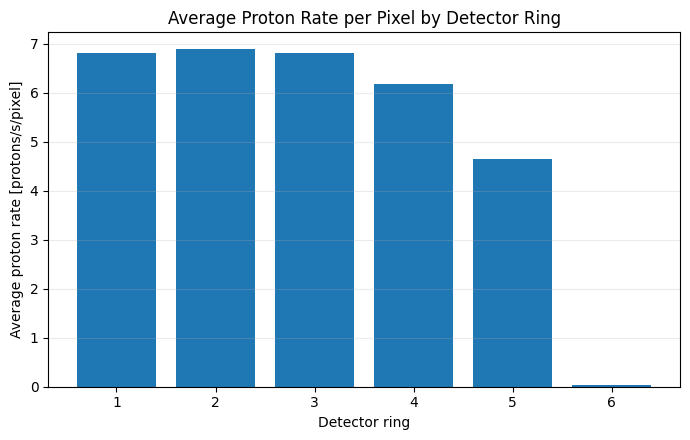

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    ring_summary["ring"],
    ring_summary["protons / s / pixel"]
)

ax.set_xlabel("Detector ring")
ax.set_ylabel("Average proton rate [protons/s/pixel]")
ax.set_title("Average Proton Rate per Pixel by Detector Ring")
ax.set_xticks(ring_summary["ring"])
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

Path("figures").mkdir(exist_ok=True)
fig.savefig(
    "figures/ring_average_rates.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

## 7. Vectorized mapping of hits to 62 detector pixels

Ring averages can hide substantial variation between individual pixels, so I also assign each nominal-position hit to one of the detector's **62 pixels**.

Rather than looping over every event individually, I use NumPy operations to perform the event-level classification and loop only over the six detector rings. The angular offsets and number of pixels per ring define the pixel boundaries within each ring.


In [ ]:
# Start every hit at 0, meaning it has not been assigned to a detector pixel
pixel_number = np.zeros(len(r_nominal), dtype=int)

# Ring 1 contains one central pixel
pixel_number[ring_1] = 1

# Ring 2: 5 pixels, each 72 degrees wide.
ring_2_phi = phi_nominal[ring_2]
ring_2_local_pixel = np.floor(ring_2_phi / 72.0).astype(int)
pixel_number[ring_2] = 2 + ring_2_local_pixel

# Ring 3: 10 pixels, each 36 degrees wide, offset by 18 degrees
ring_3_phi = (phi_nominal[ring_3] - 18.0) % 360.0
ring_3_local_pixel = np.floor(ring_3_phi / 36.0).astype(int)
pixel_number[ring_3] = 7 + ring_3_local_pixel

# Ring 4: 20 pixels, each 18 degrees wide, offset by 9 degrees
ring_4_phi = (phi_nominal[ring_4] - 9.0) % 360.0
ring_4_local_pixel = np.floor(ring_4_phi / 18.0).astype(int)
pixel_number[ring_4] = 17 + ring_4_local_pixel

# Ring 5: 10 pixels, each 36 degrees wide, offset by 18 degrees
ring_5_phi = (phi_nominal[ring_5] - 18.0) % 360.0
ring_5_local_pixel = np.floor(ring_5_phi / 36.0).astype(int)
pixel_number[ring_5] = 37 + ring_5_local_pixel

# Ring 6: 16 pixels, each 22.5 degrees wide, offset by 11.25 degrees
ring_6_phi = (phi_nominal[ring_6] - 11.25) % 360.0
ring_6_local_pixel = np.floor(ring_6_phi / 22.5).astype(int)
pixel_number[ring_6] = 47 + ring_6_local_pixel

# Count the number of hits assigned to each physical pixel number
pixel_counts_list = []

for pixel in range(1, 63):
    count = np.sum(pixel_number == pixel)
    pixel_counts_list.append(count)

pixel_counts = np.array(pixel_counts_list)
pixel_rates = pixel_counts / normalization_count * PROTONS_PER_SECOND

pixel_table = pd.DataFrame({
    "pixel": np.arange(1, 63),
    "hits": pixel_counts,
    "protons / s": pixel_rates,
})

pixel_table.head(10)


,pixel,hits,protons / s
0,1,22401,6.8075
1,2,22741,6.9108
2,3,22700,6.8983
3,4,22585,6.8634
4,5,22642,6.8807
5,6,22686,6.8941
6,7,22955,6.9758
7,8,22869,6.9497
8,9,22432,6.8169
9,10,22038,6.6972


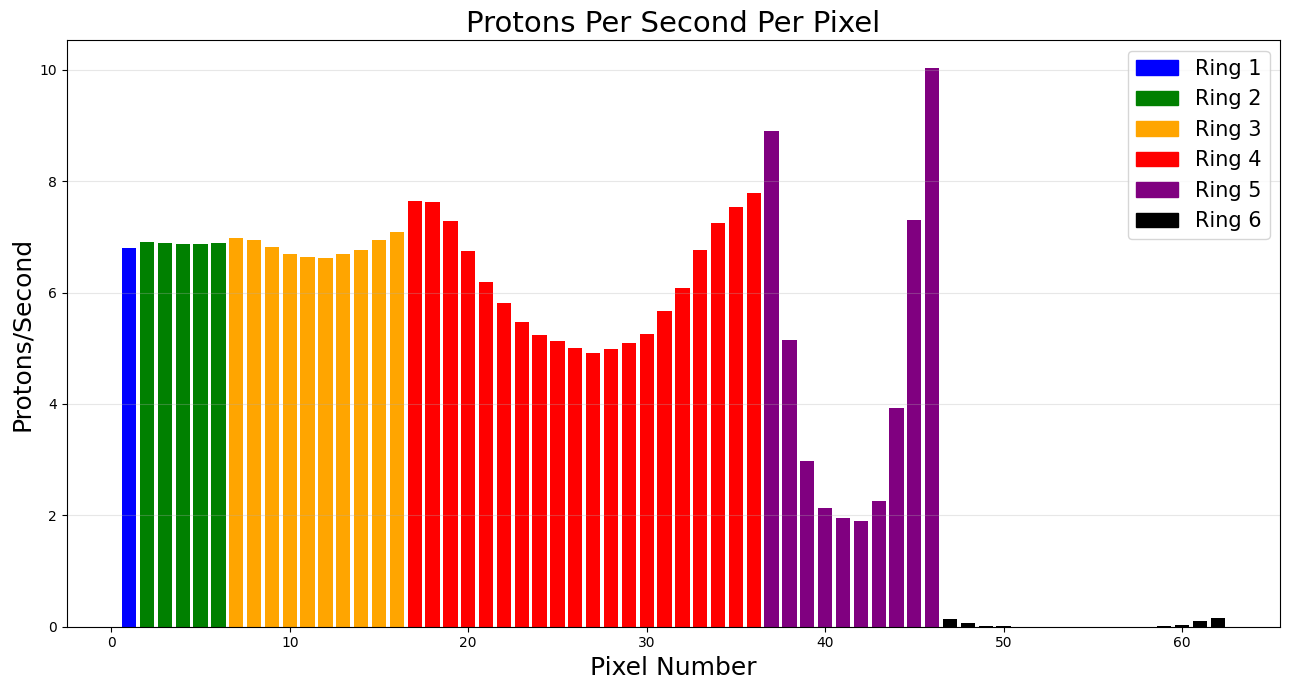

In [ ]:
# Give every pixel the color of the detector ring it belongs to
pixel_colors = (
    ["blue"]
    + ["green"] * 5
    + ["orange"] * 10
    + ["red"] * 20
    + ["purple"] * 10
    + ["black"] * 16
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.bar(
    pixel_table["pixel"],
    pixel_table["protons / s"],
    color=pixel_colors
)

ax.set_xlabel("Pixel Number", fontsize=18)
ax.set_ylabel("Protons/Second", fontsize=18)
ax.set_title("Protons Per Second Per Pixel", fontsize=21)
ax.grid(axis="y", alpha=0.3)

# Create a legend that shows which color corresponds to which detector ring
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color="blue", label="Ring 1"),
    plt.Rectangle((0, 0), 1, 1, color="green", label="Ring 2"),
    plt.Rectangle((0, 0), 1, 1, color="orange", label="Ring 3"),
    plt.Rectangle((0, 0), 1, 1, color="red", label="Ring 4"),
    plt.Rectangle((0, 0), 1, 1, color="purple", label="Ring 5"),
    plt.Rectangle((0, 0), 1, 1, color="black", label="Ring 6"),
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=15
)

fig.tight_layout()

Path("figures").mkdir(exist_ok=True)
fig.savefig(
    "figures/nominal_pixel_rates.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


## 8. Interpretation

The analysis shows several features of the simulated detector response:

- The proton-hit distribution becomes broader as the detector is moved farther from the nominal position. For the **Nominal**, **6 cm**, and **15 cm** configurations, the standard deviation increases from approximately **13.13 → 13.82 → 17.01 mm in x** and **12.46 → 13.05 → 16.41 mm in y**.
- At the nominal position, the three innermost detector rings receive similar average rates of about **6.8 protons/s/pixel**. The average rate then decreases across the outer rings.
- The pixel-level view reveals structure that is hidden by ring averages, particularly in the outer portions of the detector where rates can vary substantially from pixel to pixel.

Together, the spatial, ring-level, and pixel-level analyses show how the simulated proton distribution interacts with the detector's segmented geometry.
